# 01 — Reference Replication with Active Regularization

This notebook mirrors [`examples/two_body_reference.ipynb`](../../../examples/two_body_reference.ipynb) cell-for-cell, with one change: the base algorithm is wrapped in `RegularizedIntegrator(SymmetricProjectionIntegrator(); backend=:lifted_pair, r_on=0.5, r_off=0.7)` so that 2D Levi-Civita regularization actively engages on every periapsis passage. The goal is to demonstrate that an *actively regularized* integration reproduces the *baseline unregularized* trajectory on a well-conditioned problem.

## Weber Hamiltonian

$$H = \sum_i \frac{|\mathbf{p}_i|^2}{2m_i} + \sum_{i<j} U_{ij}, \qquad U_{ij} = \frac{q_i q_j}{r_{ij}} \left(1 - \frac{\dot r_{ij}^2}{2c^2}\right)$$

with $r_{ij} = |\mathbf{r}_i - \mathbf{r}_j|$ and $\dot r_{ij} = (\mathbf{r}_i - \mathbf{r}_j)\cdot(\mathbf{v}_i - \mathbf{v}_j)/r_{ij}$.

See [`theory/Regularization.md`](../../../theory/Regularization.md) and [`theory/RegularizedIntegrationDesign.md`](../../../theory/RegularizedIntegrationDesign.md) for the theory this notebook exercises, and the theory notebook [`02_theory.ipynb`](02_theory.ipynb) in this folder for the dense derivation.

In [1]:
include(joinpath(@__DIR__, "common.jl"))

## 1. System Construction

Canonical parameters identical to the reference: equal unit masses, unlike unit charges, $c = 4$.

In [2]:
m1, m2 = M_CANON
q1, q2 = Q_CANON_UNLIKE
c      = C_CANON

system = HamiltonianSystem(2, 2)

println("Particles:          ", system.n_particles)
println("Dimensions:         ", system.dims)
println("Degrees of freedom: ", system.degrees_of_freedom)

Particles:          2


Dimensions:         2
Degrees of freedom: 4


## 2. Symbolic Hamiltonian

The `HamiltonianSystem` stores the symbolic Hamiltonian and equations of motion for inspection. The pair-coupling constant `kappa_1_2` appears already here — it is set to $1$ for a plain Weber run and to $1 + a$ for unlike-sign pairs when Zöllner gravity is enabled (see [`06_zollner.ipynb`](06_zollner.ipynb)).

In [3]:
system.hamiltonian_symbolic

(px2^2 + py2^2) / (2m2) + (px1^2 + py1^2) / (2m1) + ((-1 + kappa_1_2)*q1*q2*(1 + (-((((x1 - x2)*((-px2) / m2 + px1 / m1) + (y1 - y2)*((-py2) / m2 + py1 / m1)) / sqrt((x1 - x2)^2 + (y1 - y2)^2))^2)) / (2(c^2)))) / sqrt((x1 - x2)^2 + (y1 - y2)^2) + (q1*q2*(1 + (-((((x1 - x2)*((-px2) / m2 + px1 / m1) + (y1 - y2)*((-py2) / m2 + py1 / m1)) / sqrt((x1 - x2)^2 + (y1 - y2)^2))^2)) / (2(c^2)))) / sqrt((x1 - x2)^2 + (y1 - y2)^2)

In [4]:
system.dp_dt_symbolic[1]  # Force on particle 1, x-component

-((-q1*q2*((x1 - x2)*((-px2) / m2 + px1 / m1) + (y1 - y2)*((-py2) / m2 + py1 / m1))*(((-px2) / m2 + px1 / m1) / sqrt((x1 - x2)^2 + (y1 - y2)^2) + (-(x1 - x2)*((x1 - x2)*((-px2) / m2 + px1 / m1) + (y1 - y2)*((-py2) / m2 + py1 / m1))) / (((x1 - x2)^2 + (y1 - y2)^2)*sqrt((x1 - x2)^2 + (y1 - y2)^2)))) / ((c^2)*((x1 - x2)^2 + (y1 - y2)^2))) - ((-q1*q2*(x1 - x2)*(1 + (-((((x1 - x2)*((-px2) / m2 + px1 / m1) + (y1 - y2)*((-py2) / m2 + py1 / m1)) / sqrt((x1 - x2)^2 + (y1 - y2)^2))^2)) / (2(c^2)))) / (((x1 - x2)^2 + (y1 - y2)^2)*sqrt((x1 - x2)^2 + (y1 - y2)^2))) - ((-(-1 + kappa_1_2)*q1*q2*(x1 - x2)*(1 + (-((((x1 - x2)*((-px2) / m2 + px1 / m1) + (y1 - y2)*((-py2) / m2 + py1 / m1)) / sqrt((x1 - x2)^2 + (y1 - y2)^2))^2)) / (2(c^2)))) / (((x1 - x2)^2 + (y1 - y2)^2)*sqrt((x1 - x2)^2 + (y1 - y2)^2))) - ((-(-1 + kappa_1_2)*q1*q2*((x1 - x2)*((-px2) / m2 + px1 / m1) + (y1 - y2)*((-py2) / m2 + py1 / m1))*(((-px2) / m2 + px1 / m1) / sqrt((x1 - x2)^2 + (y1 - y2)^2) + (-(x1 - x2)*((x1 - x2)*((-px2) / m2 + p

In [5]:
system.dq_dt_symbolic[1]  # Velocity of particle 1, x-component

(-(-1 + kappa_1_2)*q1*q2*(x1 - x2)*((x1 - x2)*((-px2) / m2 + px1 / m1) + (y1 - y2)*((-py2) / m2 + py1 / m1))) / ((c^2)*m1*(sqrt((x1 - x2)^2 + (y1 - y2)^2)^3)) + (-q1*q2*(x1 - x2)*((x1 - x2)*((-px2) / m2 + px1 / m1) + (y1 - y2)*((-py2) / m2 + py1 / m1))) / ((c^2)*m1*(sqrt((x1 - x2)^2 + (y1 - y2)^2)^3)) + px1 / m1

## 3. Problem Setup

Symmetric initial conditions in the centre-of-mass frame: particles at $(\pm 1, 0)$ with momenta $(0, \mp 1/4)$. The starting configuration is at the **apoapsis** of a Kepler ellipse with eccentricity $e = 3/4$, semi-major axis $a = 8/7$, and period

$$T = 2\pi \sqrt{\tfrac{a^3 \mu}{|k|}} \approx 5.4282,\qquad \mu = \tfrac{m_1 m_2}{m_1 + m_2} = \tfrac{1}{2}, \qquad k = q_1 q_2 = -1.$$

The periapsis is $r_{\text{peri}} = a(1-e) = 8/7 \cdot 1/4 \approx 0.286$, so with $r_{\text{on}} = 0.5$ and $r_{\text{off}} = 0.7$ the regularizer activates near every periapsis passage.

In [6]:
q0 = [-1.0, 0.0, 1.0, 0.0]
p0 = [ 0.0, -0.25, 0.0, 0.25]

mu = m1 * m2 / (m1 + m2)
a_semi = 8 / 7
T_orbit = 2π * sqrt(a_semi^3 * mu / abs(q1 * q2))
tspan = (0.0, 5 * T_orbit)

println("Orbital period:   ", round(T_orbit, digits = 4))
println("Simulation time:  ", round(tspan[2], digits = 4), " (5 orbits)")
println("Periapsis (est):  ", round(a_semi * (1 - 0.75), digits = 4))

Orbital period:   5.4282
Simulation time:  27.1408 (5 orbits)
Periapsis (est):  0.2857


## 4. Regularized Problem

We activate **2D Levi-Civita** regularization via `:lifted_pair` with explicit activation radii. The effect is local: outside $r_{\text{off}}$ the solver runs the usual Cartesian projected kernel; inside $r_{\text{on}}$ it lifts the pair to Levi-Civita $(u, U)$ coordinates with $dt = r\,d\tau$, and hysteresis between the two thresholds prevents mode-hopping.

In [7]:
prob = HamiltonianProblem(system, tspan, q0, p0;
    masses  = [m1, m2],
    charges = [q1, q2],
    c       = c,
    dt      = 0.001,
)

alg = canonical_2d_algorithm(
    regularization = (
        backend      = :lifted_pair,
        r_on         = 0.5,
        r_off        = 0.7,
        max_substeps = 256,
    ),
)

RegularizedIntegrator{SymmetricProjectionIntegrator}(SymmetricProjectionIntegrator(0.25), RegularizationOptions(true, 0.5, 0.7, 0.15, 0.25, 256, 1.0e-12, 1.0e-12, true, :lifted_pair, true, 0.0))

## 5. Integration

Solve with the CommonSolve interface.

In [8]:
sol = solve(prob, alg)

println("Return code: ", sol.retcode)
println("Time steps:  ", length(sol.t))

Return code: Success


Time steps:  27142


### Stepped integration

For fine-grained control, `init`/`step!`/`solve!` work identically whether or not regularization is enabled.

In [9]:
integrator = init(prob, alg)
for _ in 1:10
    step!(integrator)
end
println("After 10 steps: t = ", round(integrator.t, digits = 4))
sol_stepped = solve!(integrator)
println("Final time: ", round(sol_stepped.t[end], digits = 2))

After 10 steps: t = 0.01
Final time: 

27.14


## 6. Baseline (Unregularized) Run

Build the same problem with `enabled=false` and integrate for comparison. This is the reference trajectory we want the regularized run to match.

In [10]:
prob_base = canonical_2d_problem()  # reg disabled by default
sol_base  = solve(prob_base)
println("Baseline retcode: ", sol_base.retcode)

Baseline retcode: Success

## 7. Trajectory Analysis

Overlay the regularized and baseline trajectories via `plot_trajectories`. In a well-conditioned 2D Kepler problem the two should be visually indistinguishable.

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


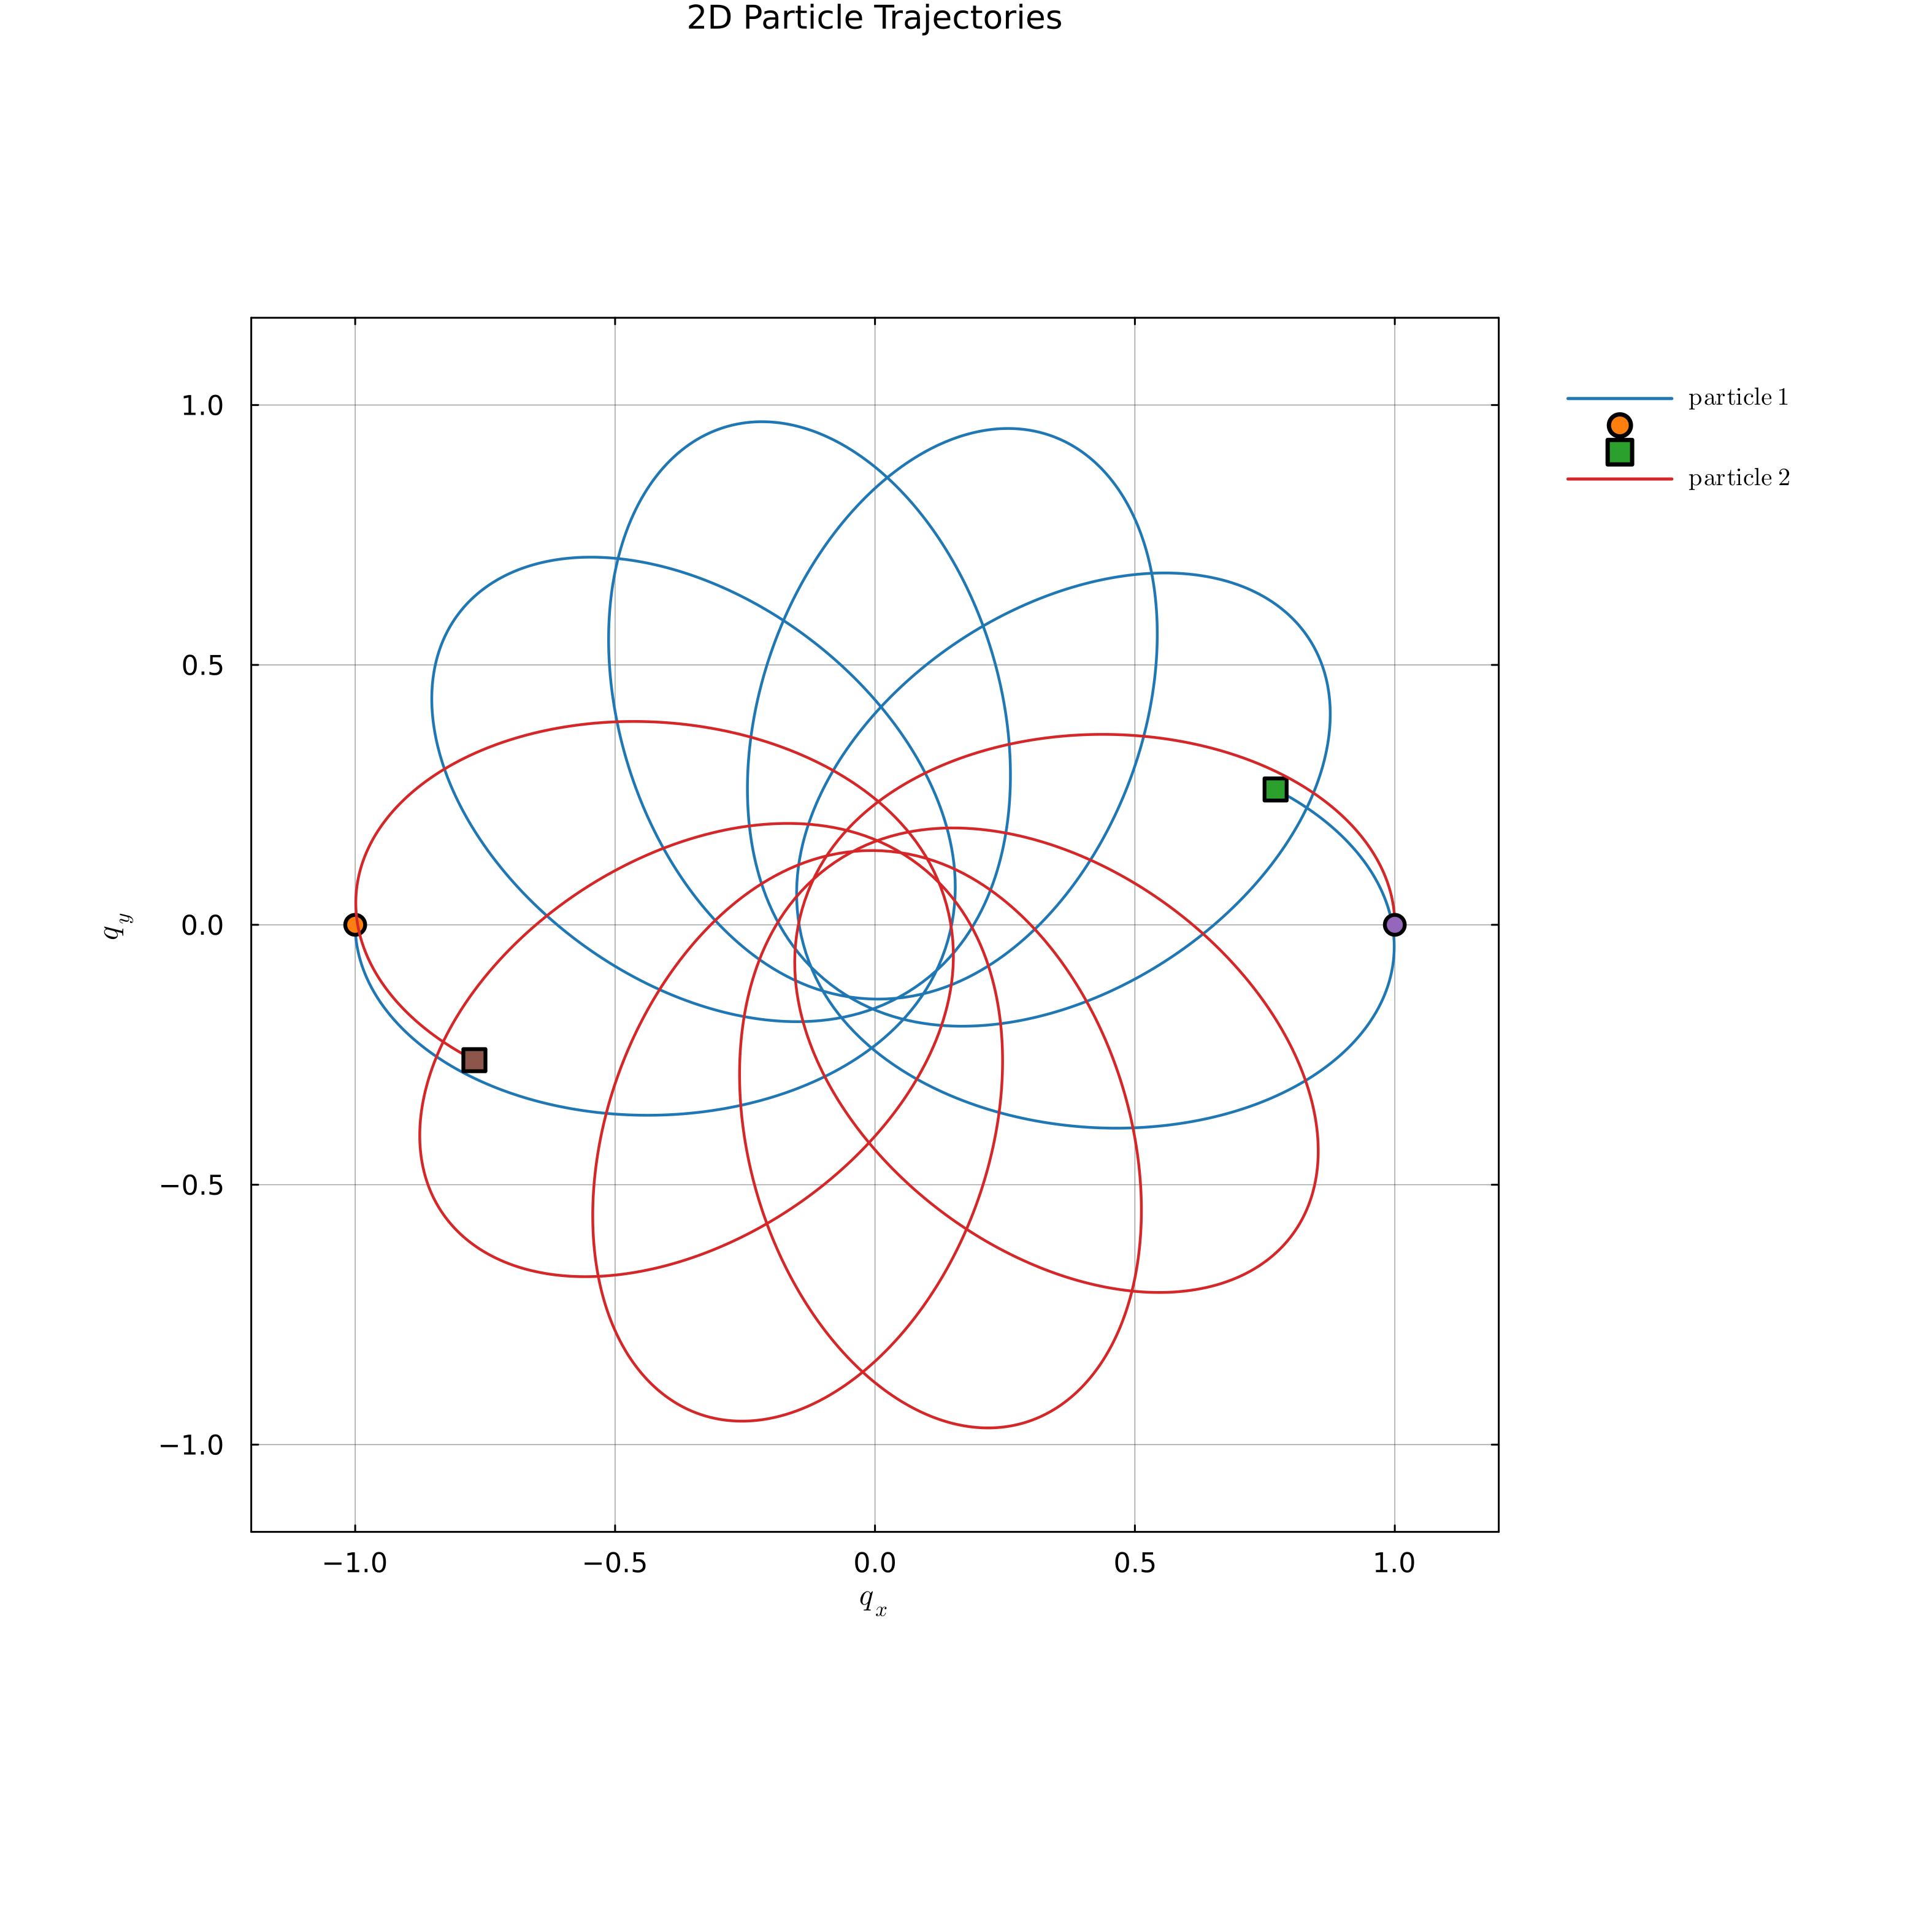

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [11]:
traj_reg  = compute_trajectory_data(sol,      2, 2; stride = 10)
traj_base = compute_trajectory_data(sol_base, 2, 2; stride = 10)

plt_traj_reg = plot_trajectories(traj_reg)
savefig(plt_traj_reg, joinpath(figures_dir(), "01_trajectories_regularized.png"))
plt_traj_reg

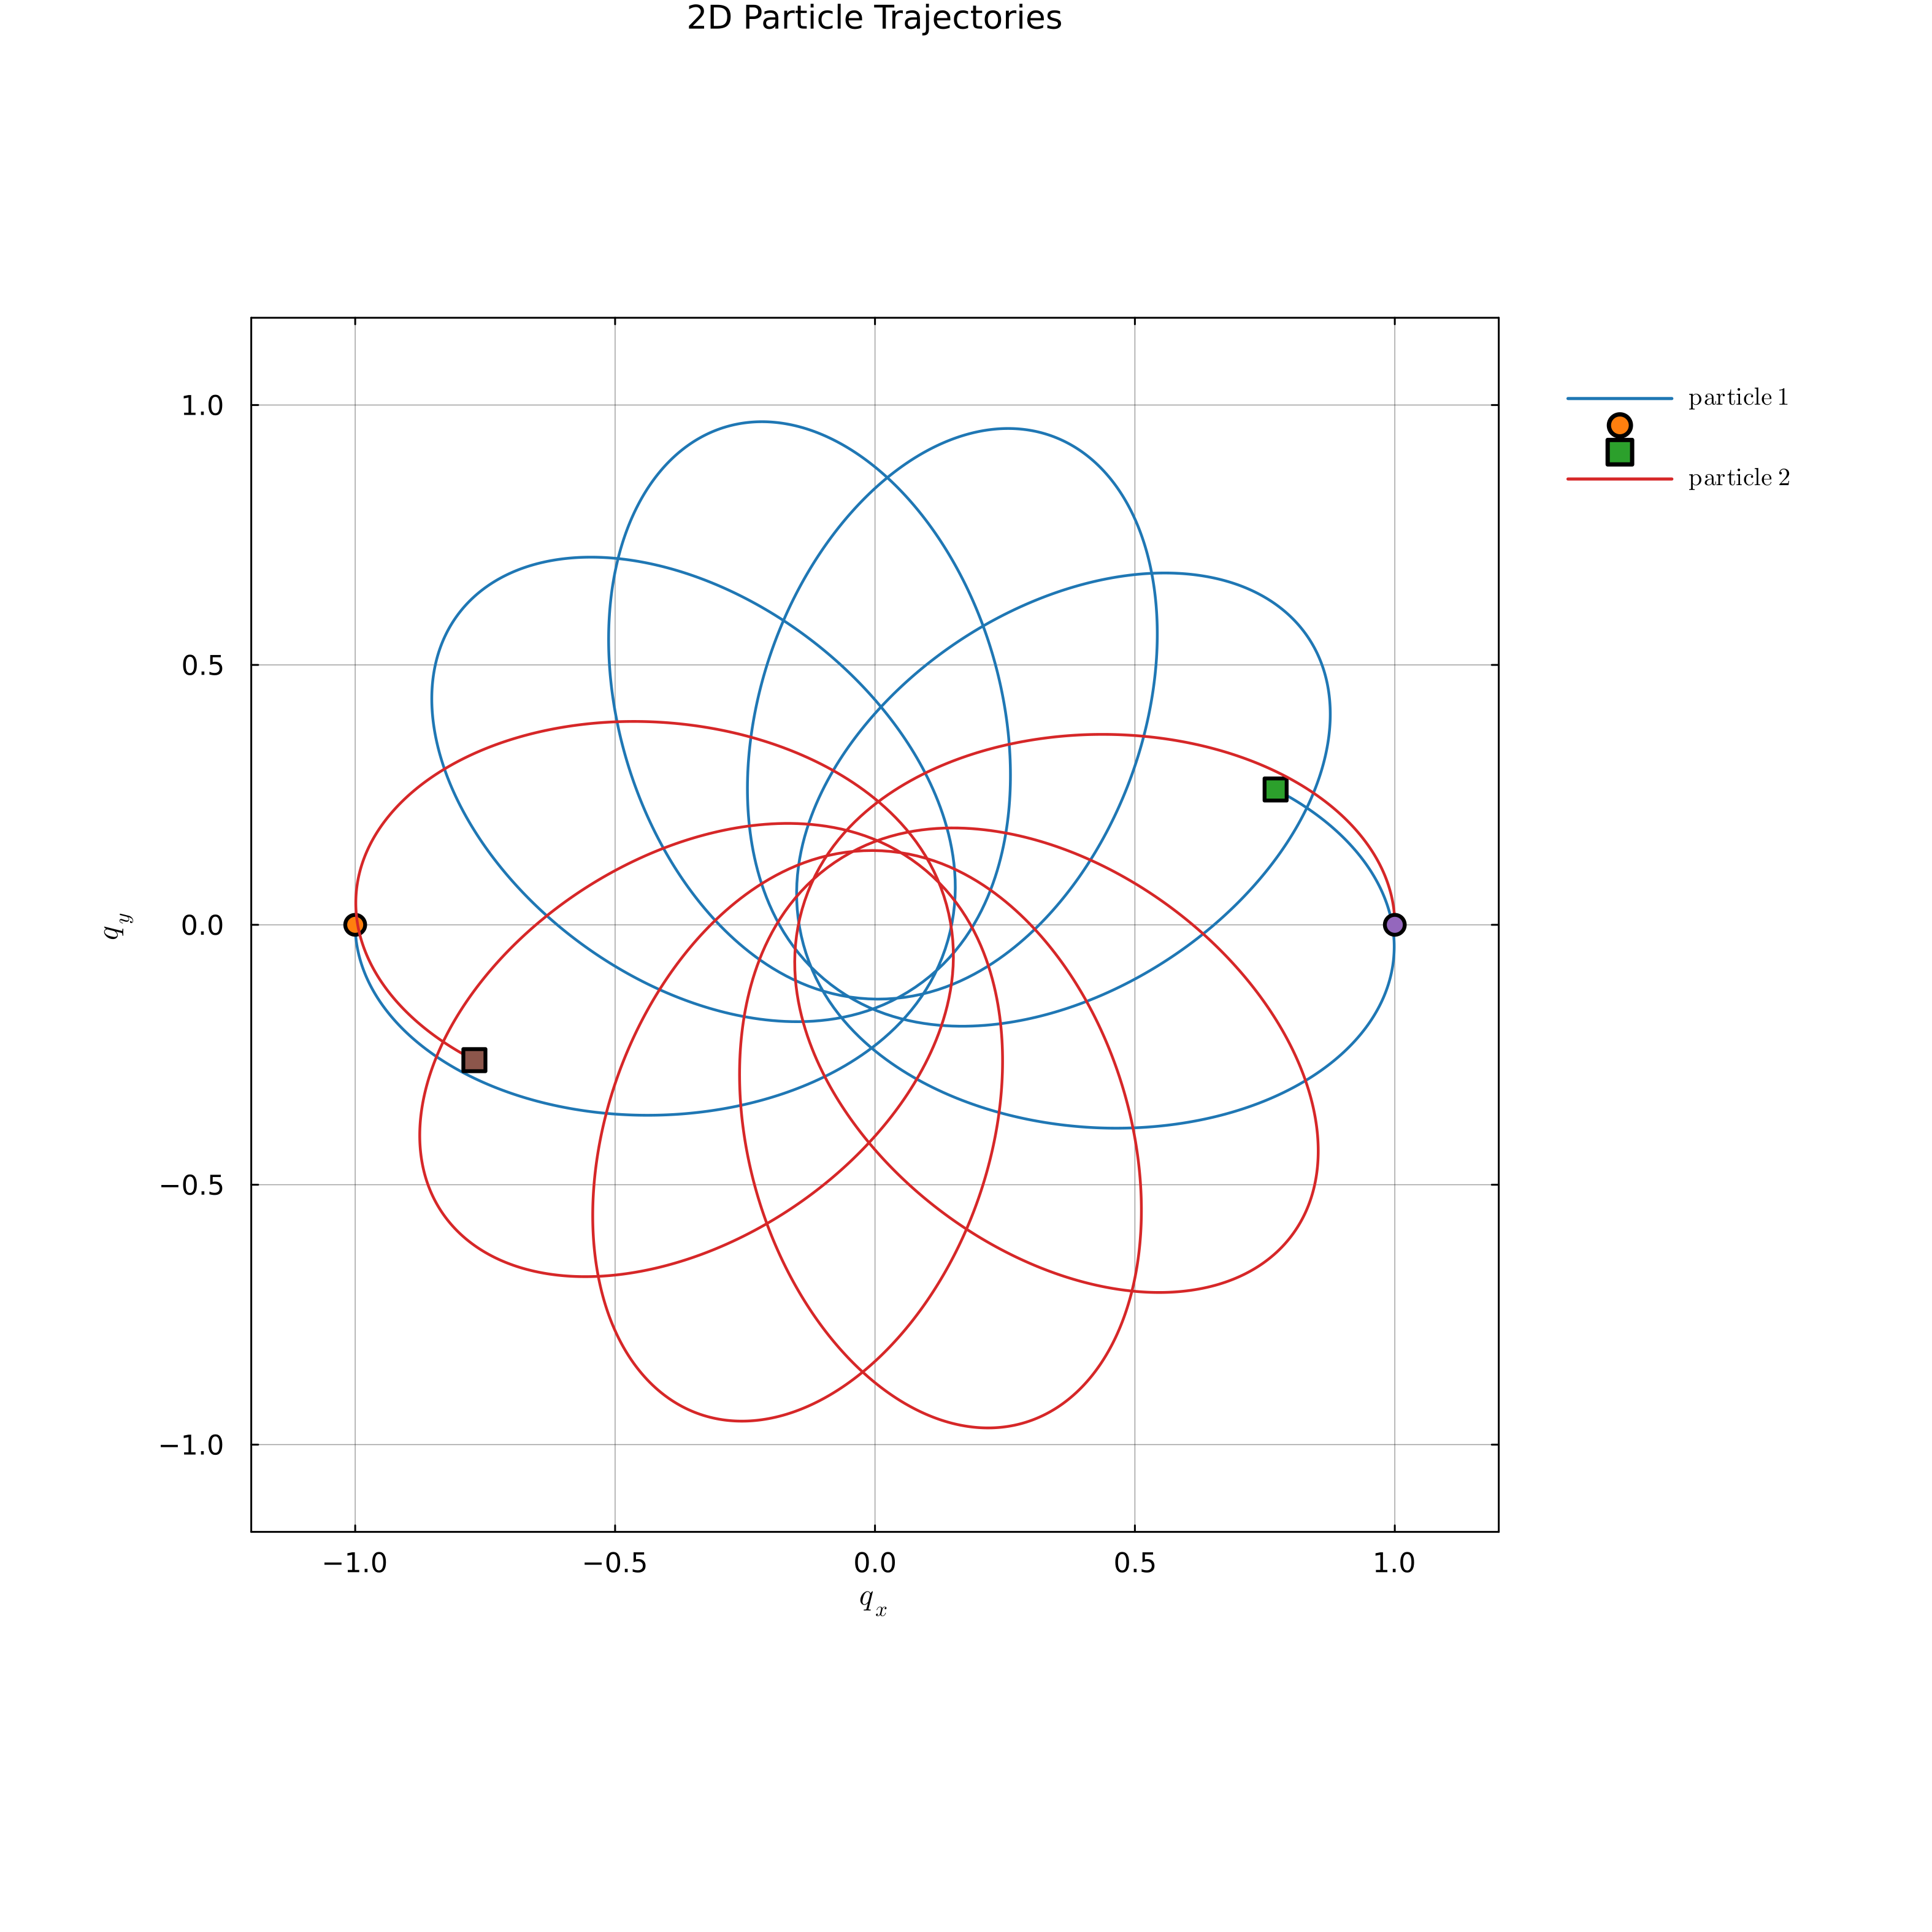

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [12]:
plot_trajectories(traj_base)

## 8. Energy Conservation

The package-level `plot_energy`, `plot_pair_energy`, and `plot_energy_errors` functions exhaust the diagnostics available from `compute_energy_timeseries`.

Statistics:


  Max local error:  1.17e-07
  Max global error: 1.43e-04%
  Hamiltonian validation: 4.44e-16


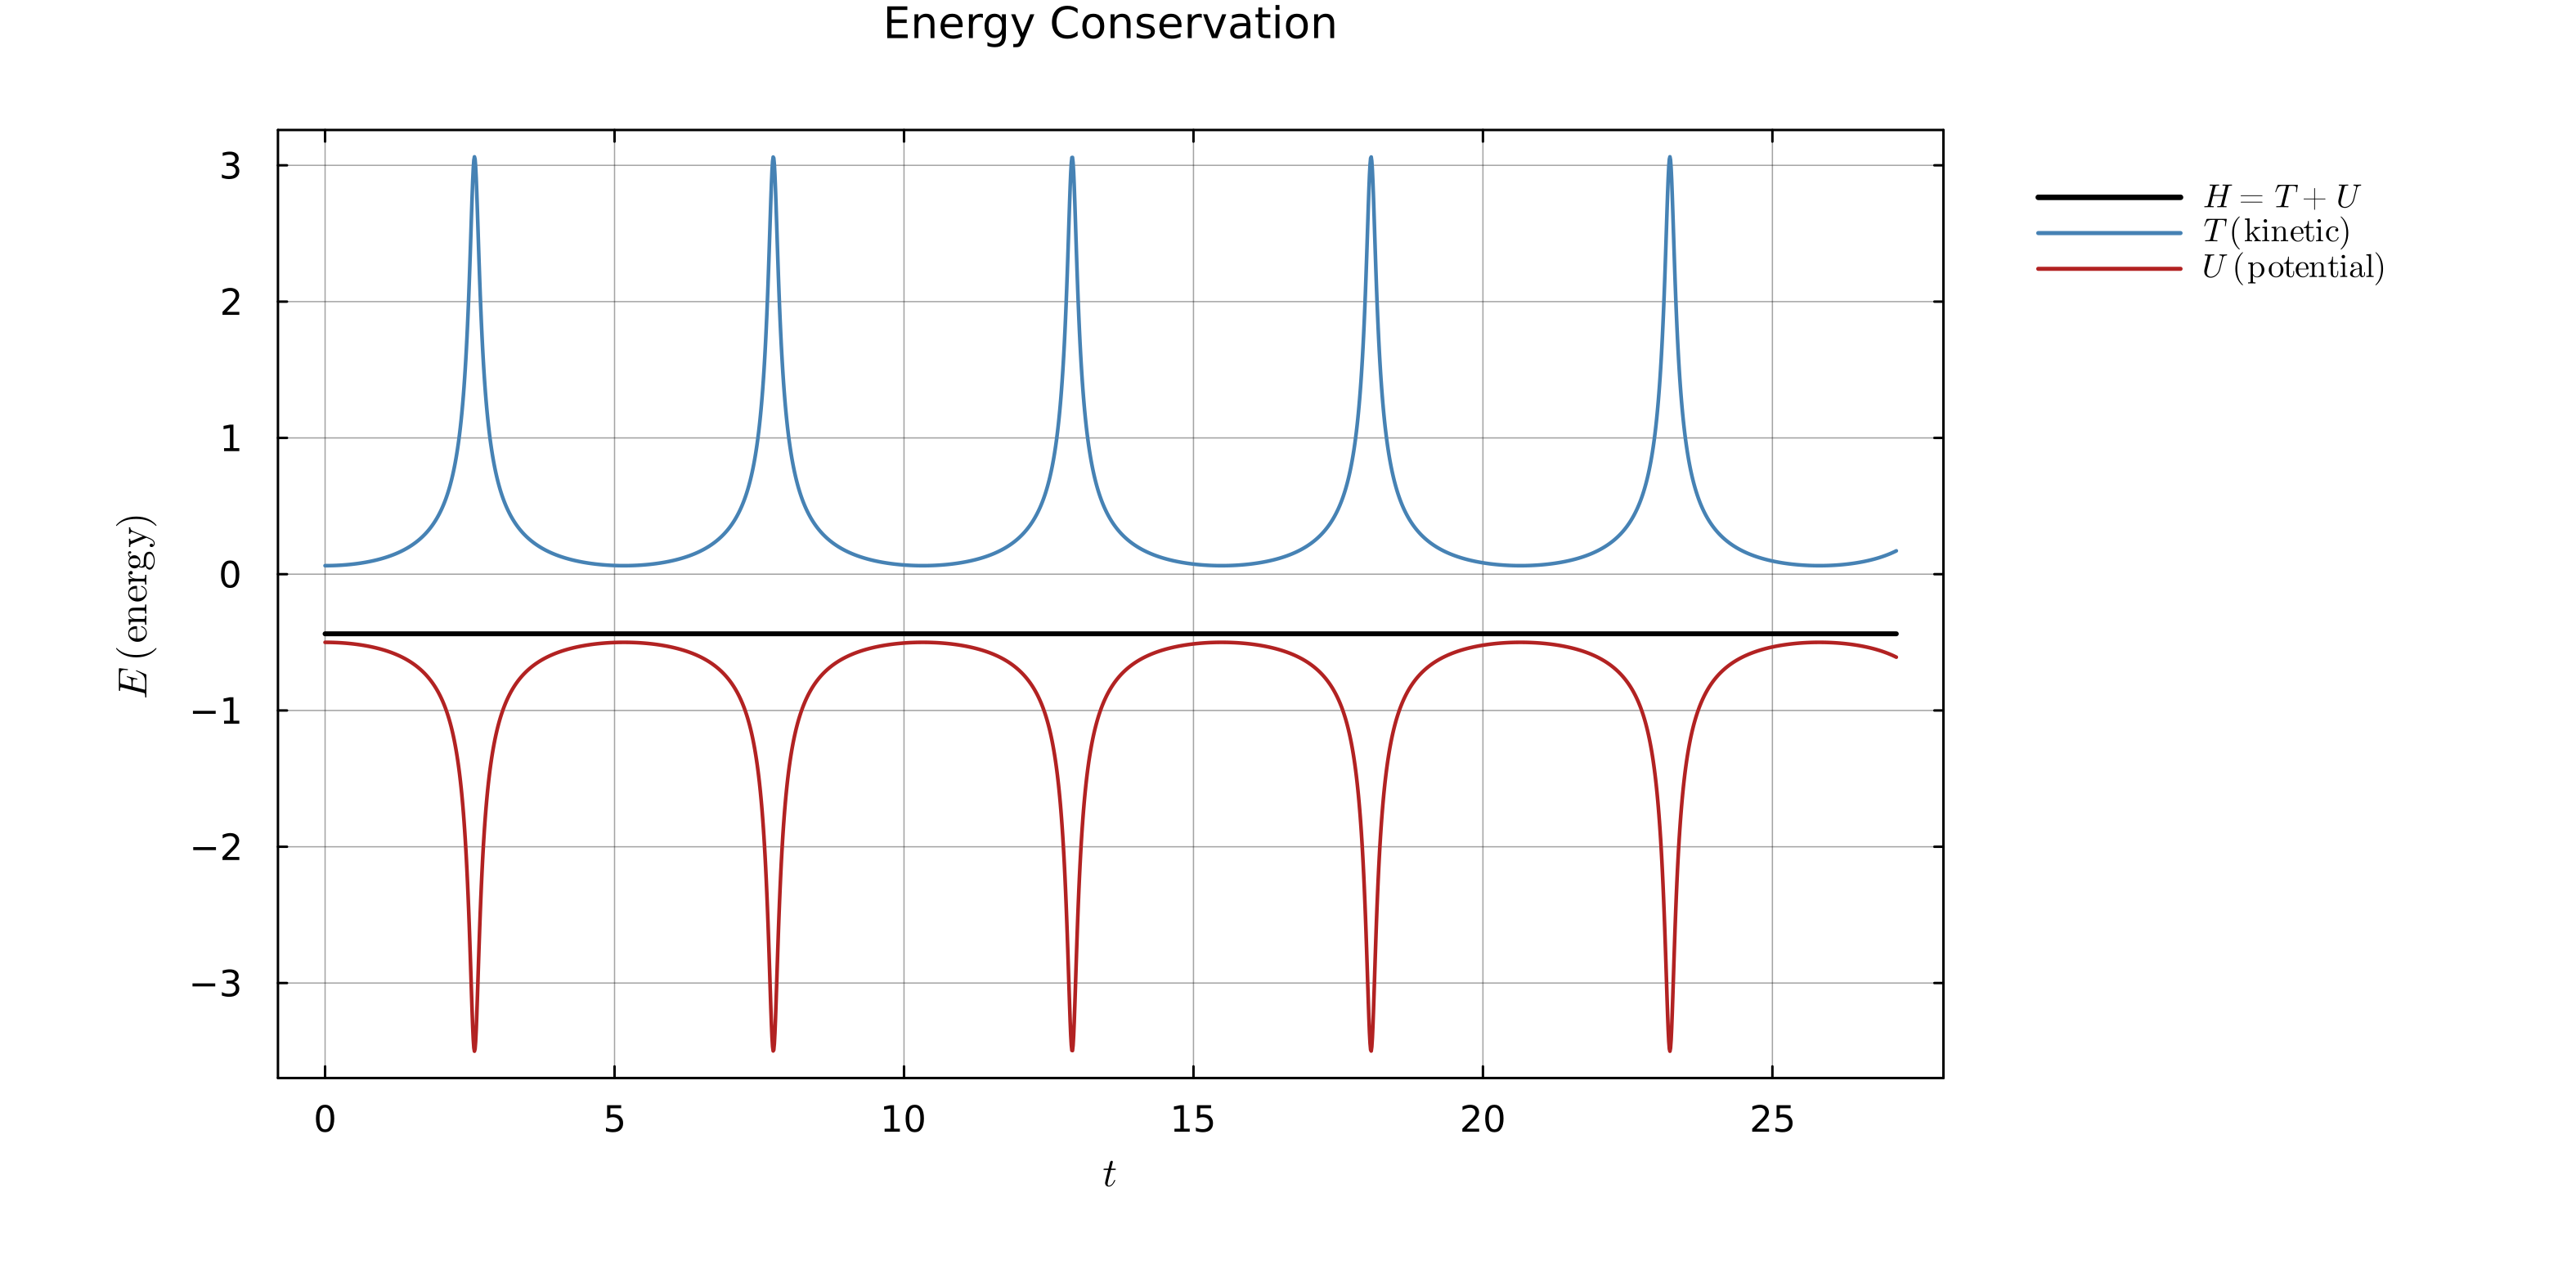

In [13]:
energy = compute_energy_timeseries(sol; stride = 10)

println("Statistics:")
println("  Max local error:  ", @sprintf("%.2e", energy.statistics.local_error_max))
println("  Max global error: ", @sprintf("%.2e%%", energy.statistics.global_error_percent_max))
println("  Hamiltonian validation: ", @sprintf("%.2e", maximum(energy.hamiltonian_validation_error)))

plt_energy = plot_energy(energy)
savefig(plt_energy, joinpath(figures_dir(), "01_energy.png"))
plt_energy

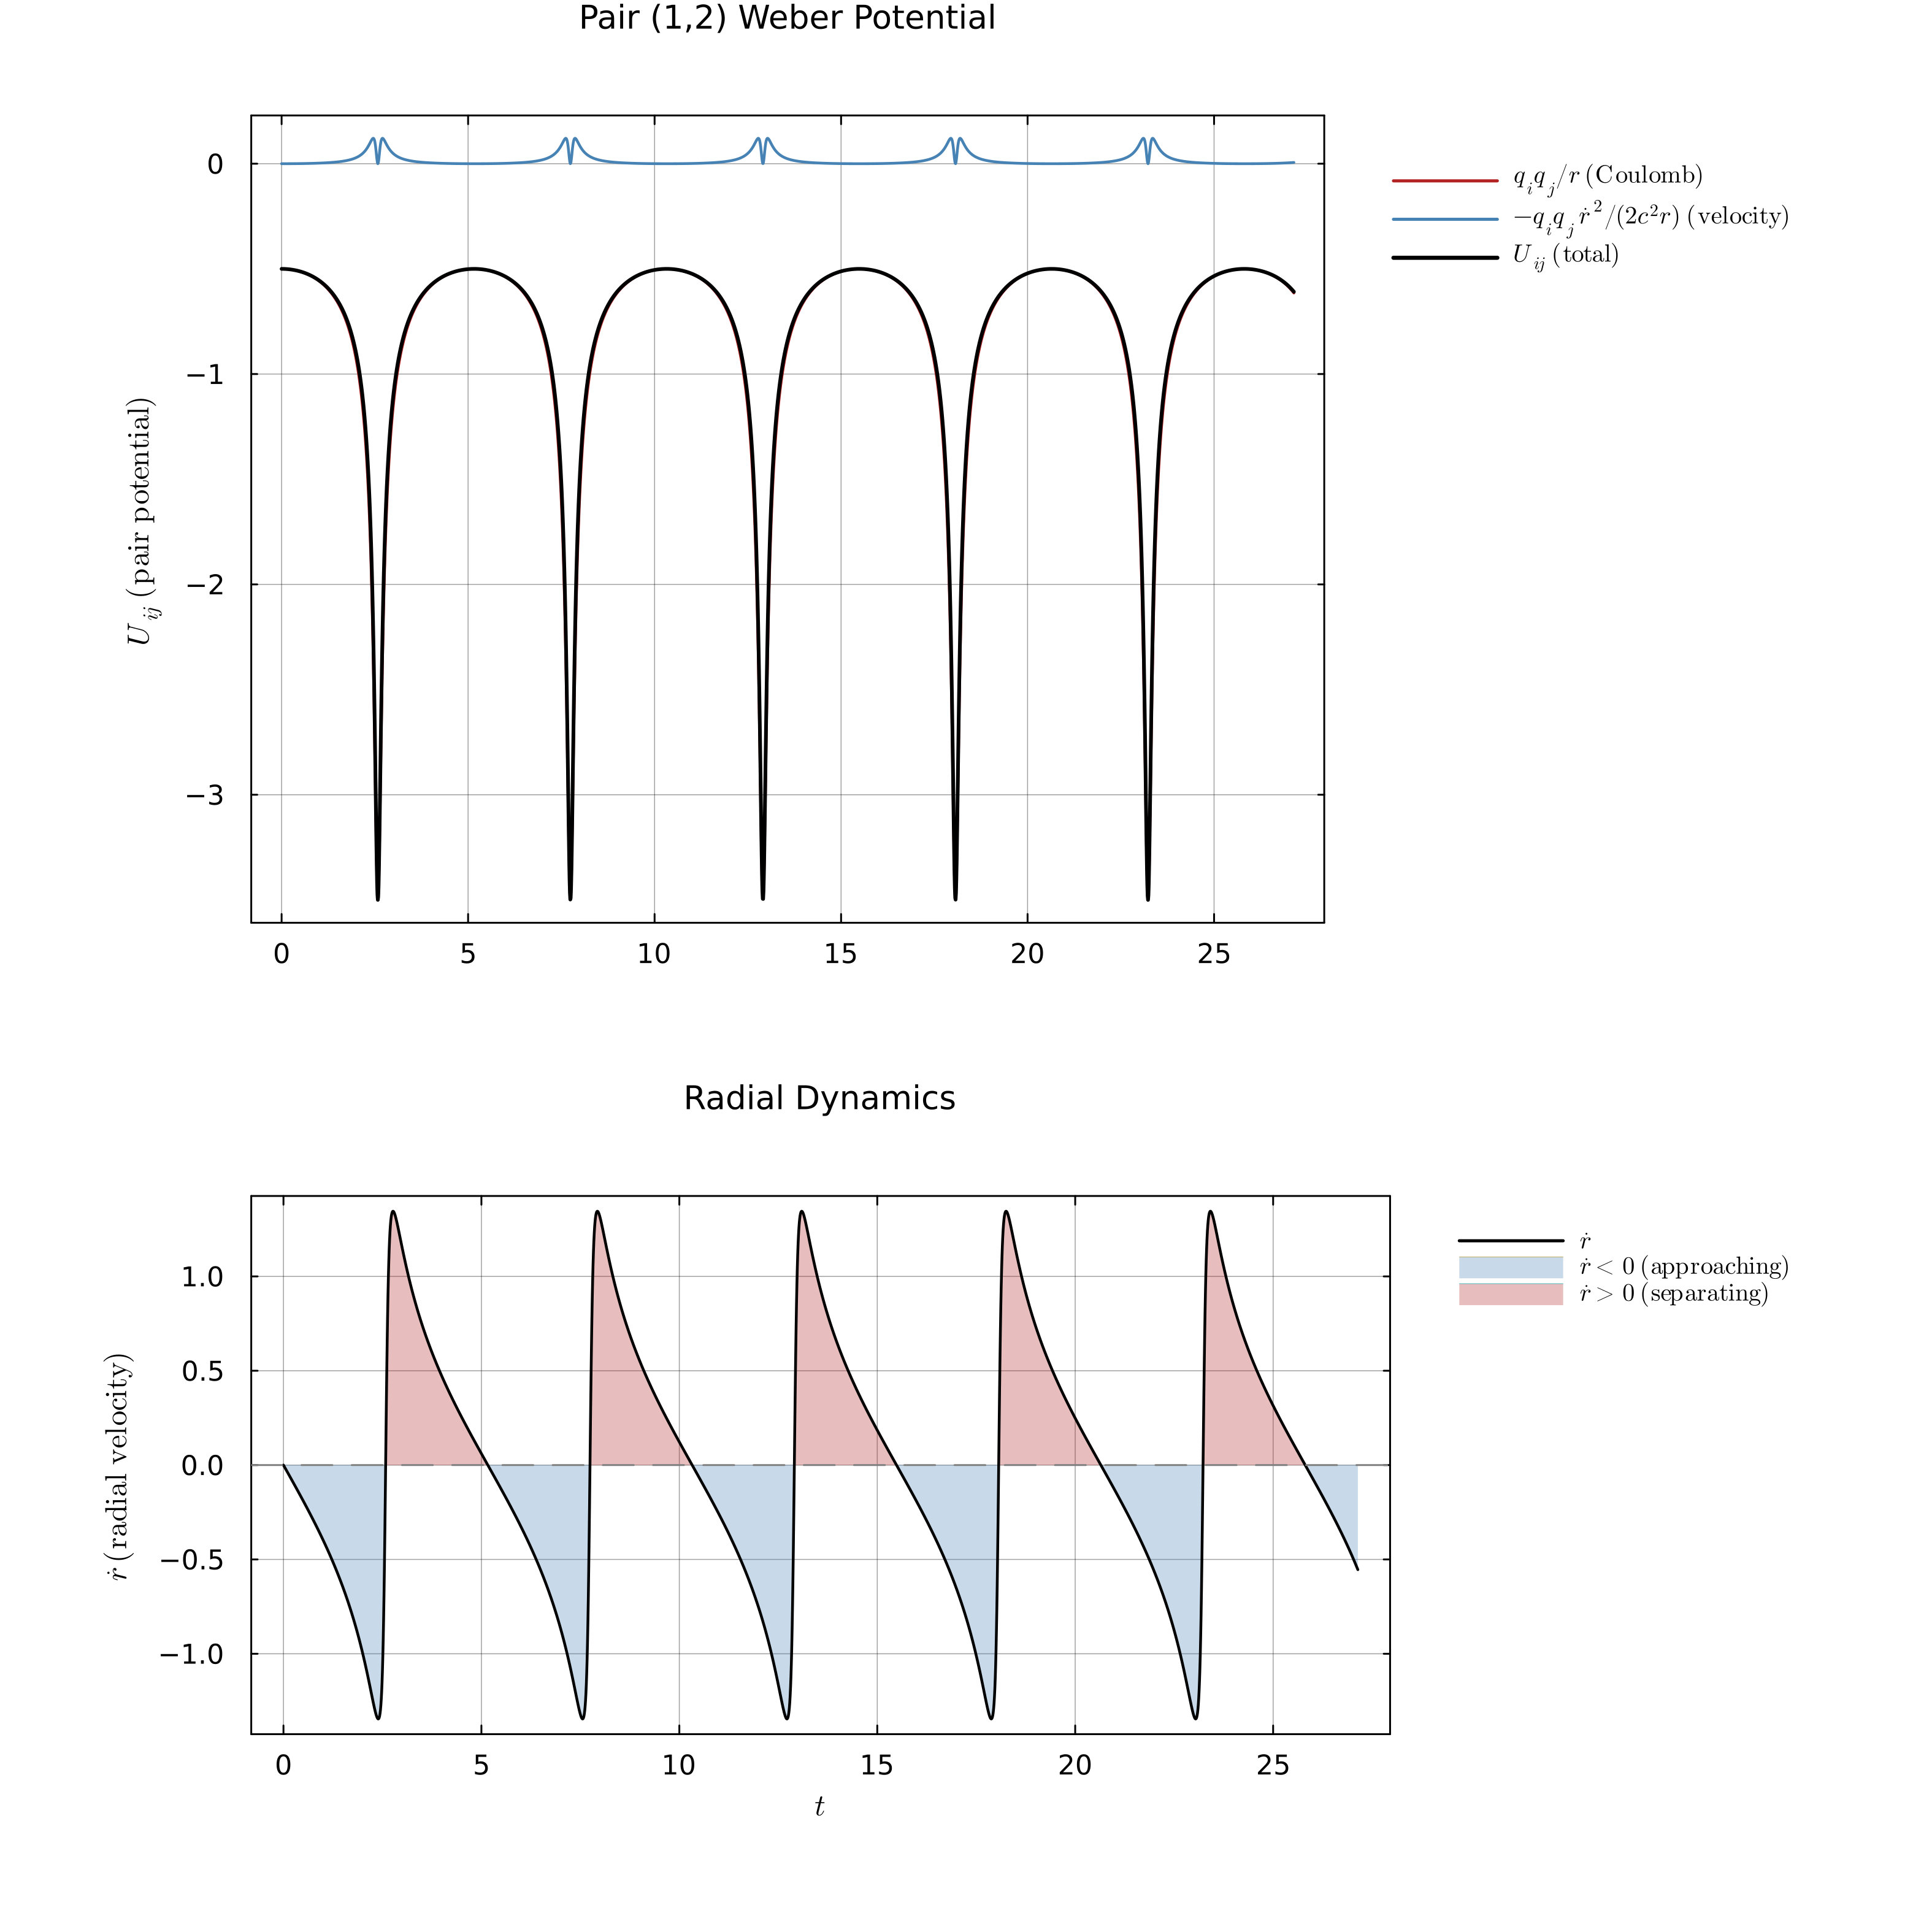

In [14]:
plot_pair_energy(energy, (1, 2))

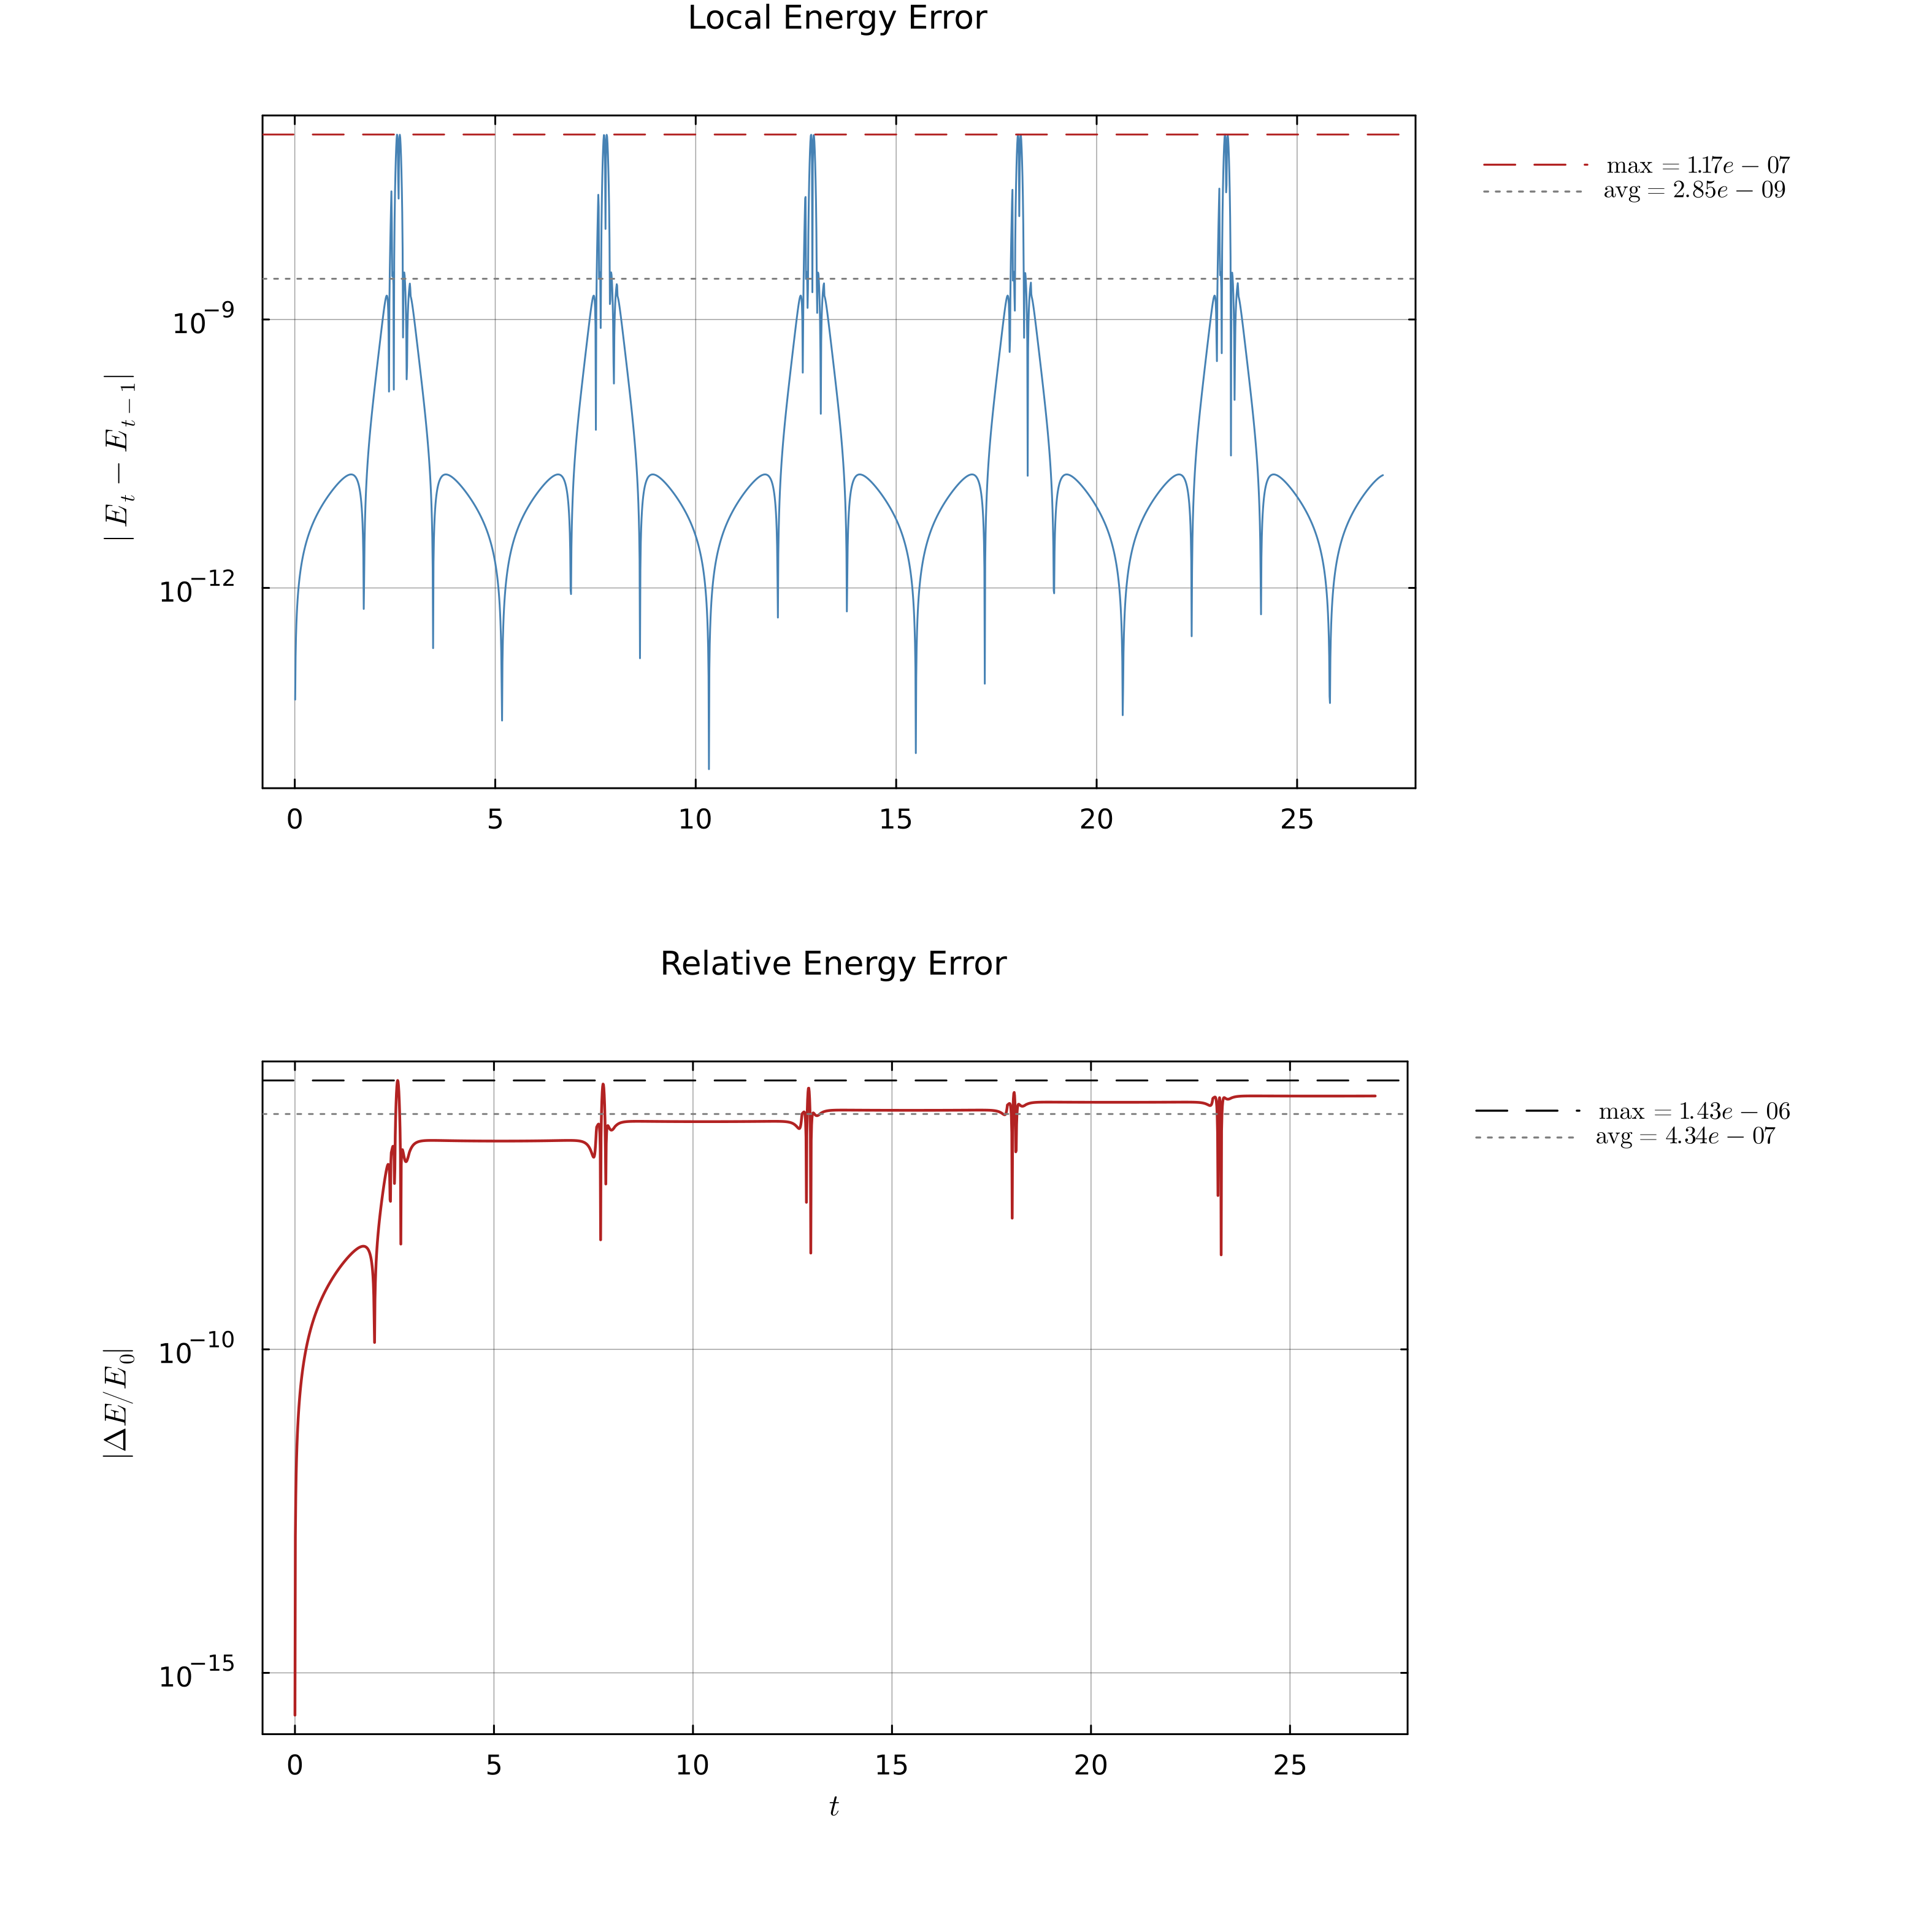

In [15]:
plt_errors = plot_energy_errors(energy)
savefig(plt_errors, joinpath(figures_dir(), "01_energy_errors.png"))
plt_errors

## 9. Force Analysis

`plot_pair_forces` lays out four panels: magnitude with min/max/mean, Cartesian components, vector decomposition into Coulomb + velocity corrections, and the radial decomposition.

Force statistics:


  Min:   2.3828e-01
  Max:   1.6313e+01
  Mean:  1.0970e+00


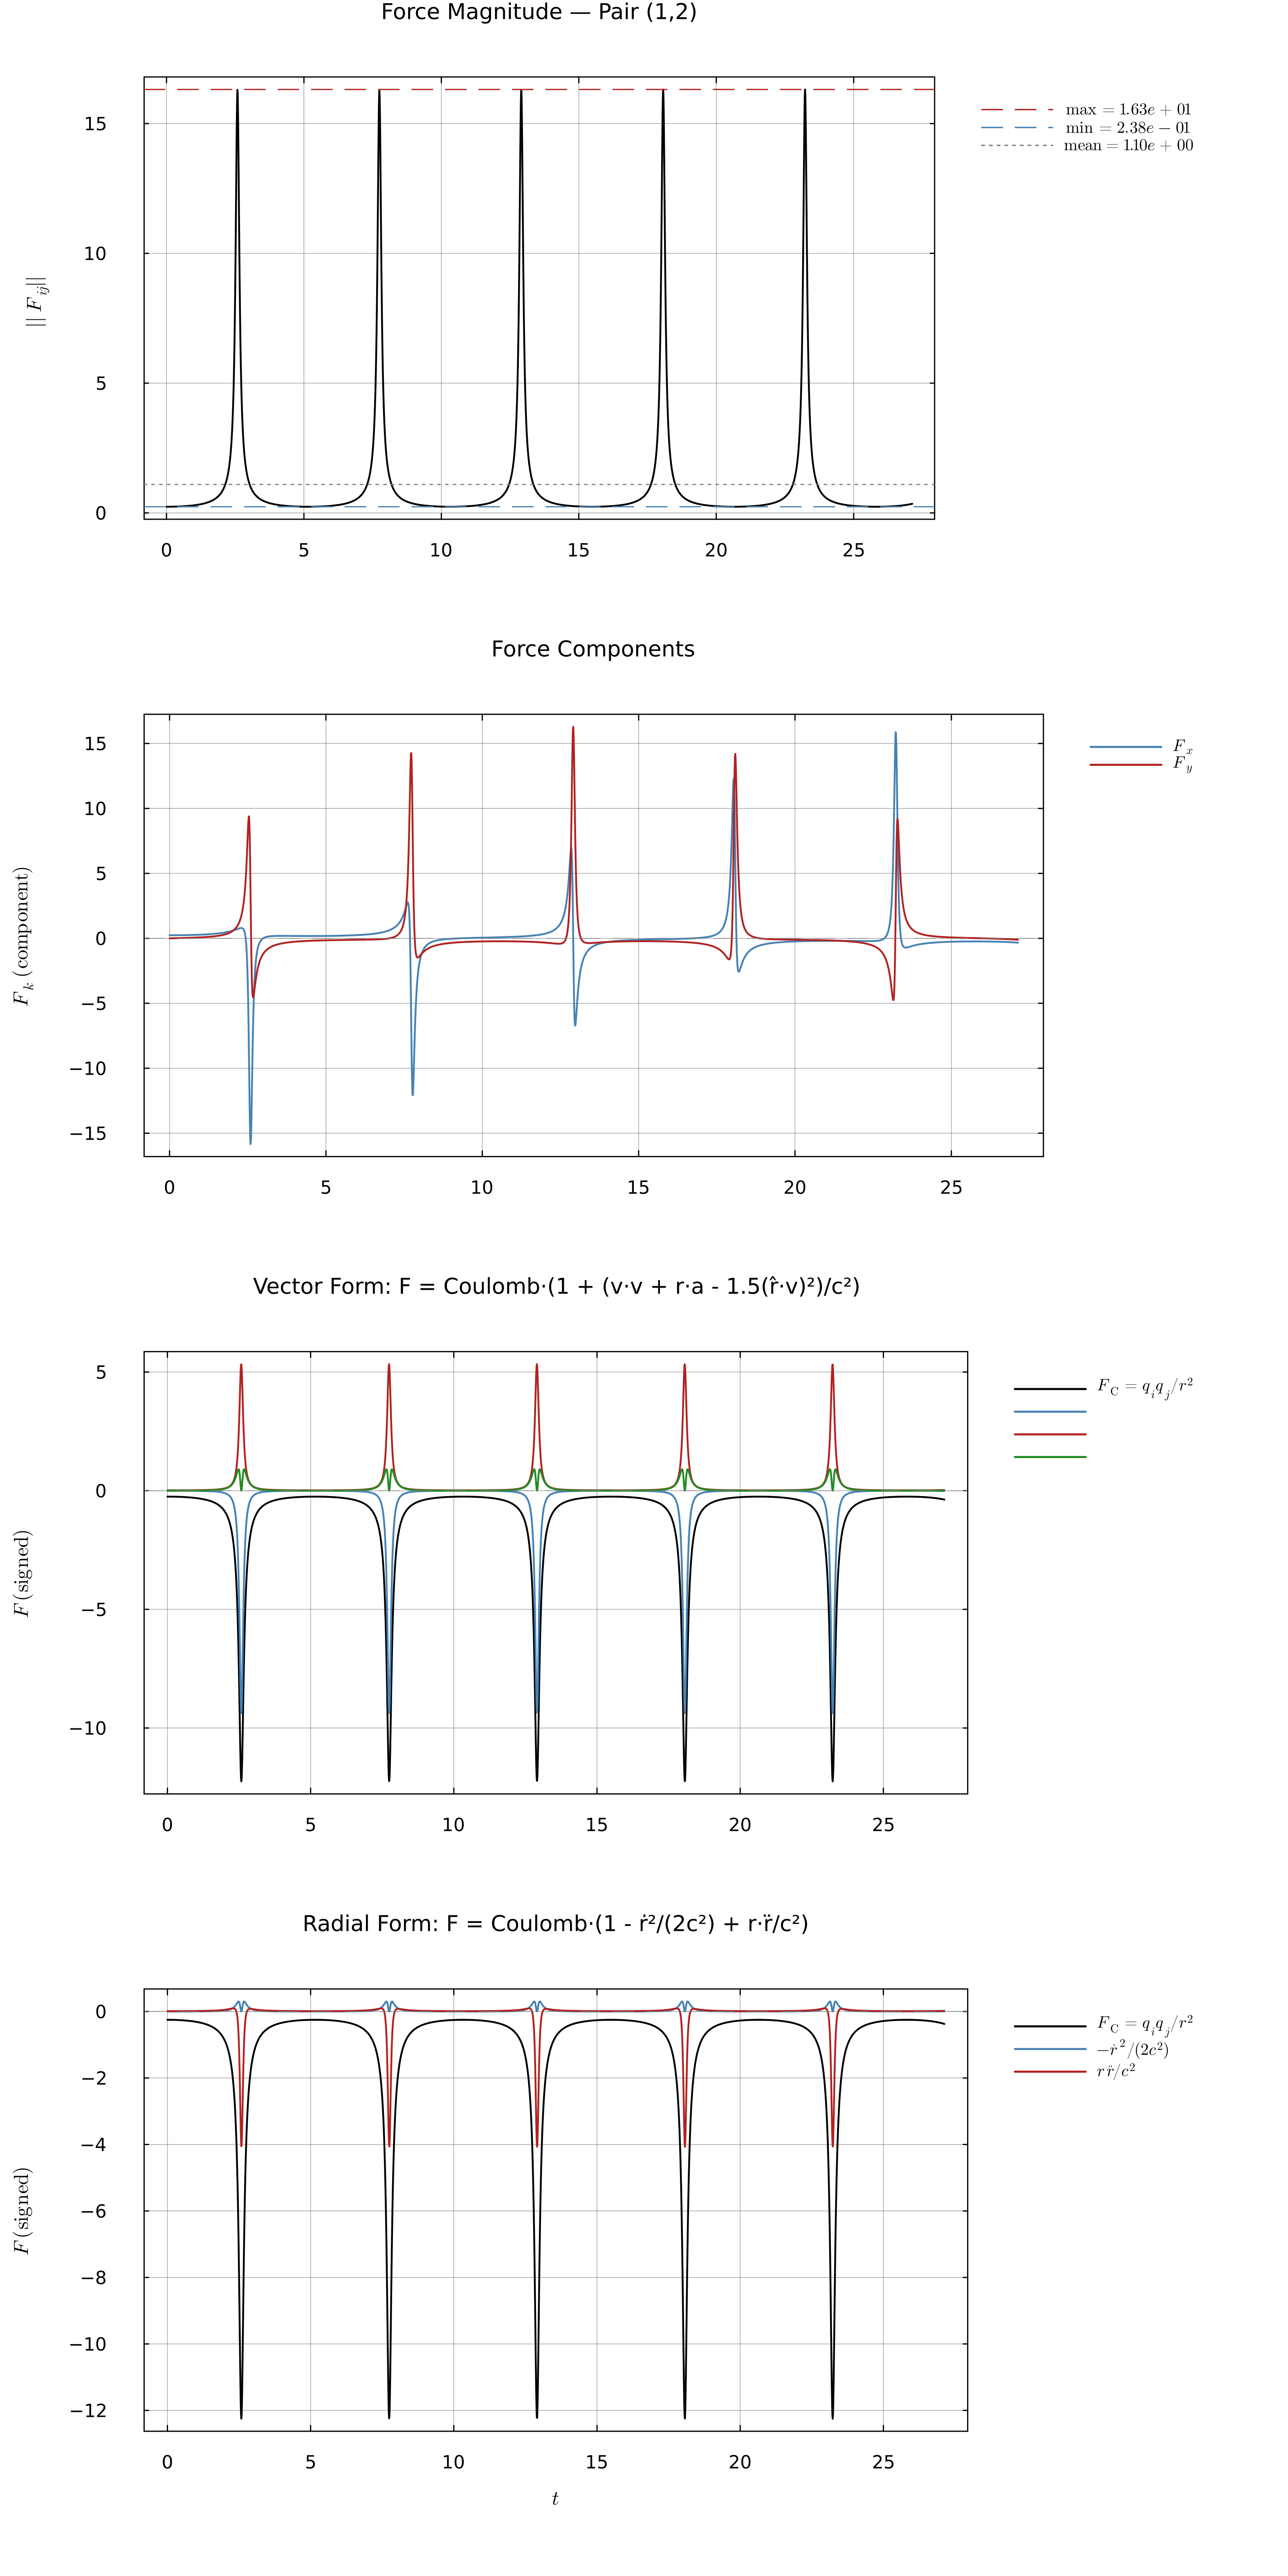

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [16]:
forces = compute_pair_force_timeseries(sol, (1, 2), 2, 2, [m1, m2], [q1, q2], c; stride = 10)

println("Force statistics:")
println("  Min:   ", @sprintf("%.4e", forces.stats.min))
println("  Max:   ", @sprintf("%.4e", forces.stats.max))
println("  Mean:  ", @sprintf("%.4e", forces.stats.mean))

plot_pair_forces(forces)

## 10. Phase Space

$(r, \dot r)$ relative-motion portrait embedded in the force data.

Min separation: 0.2857
Max separation: 2.0


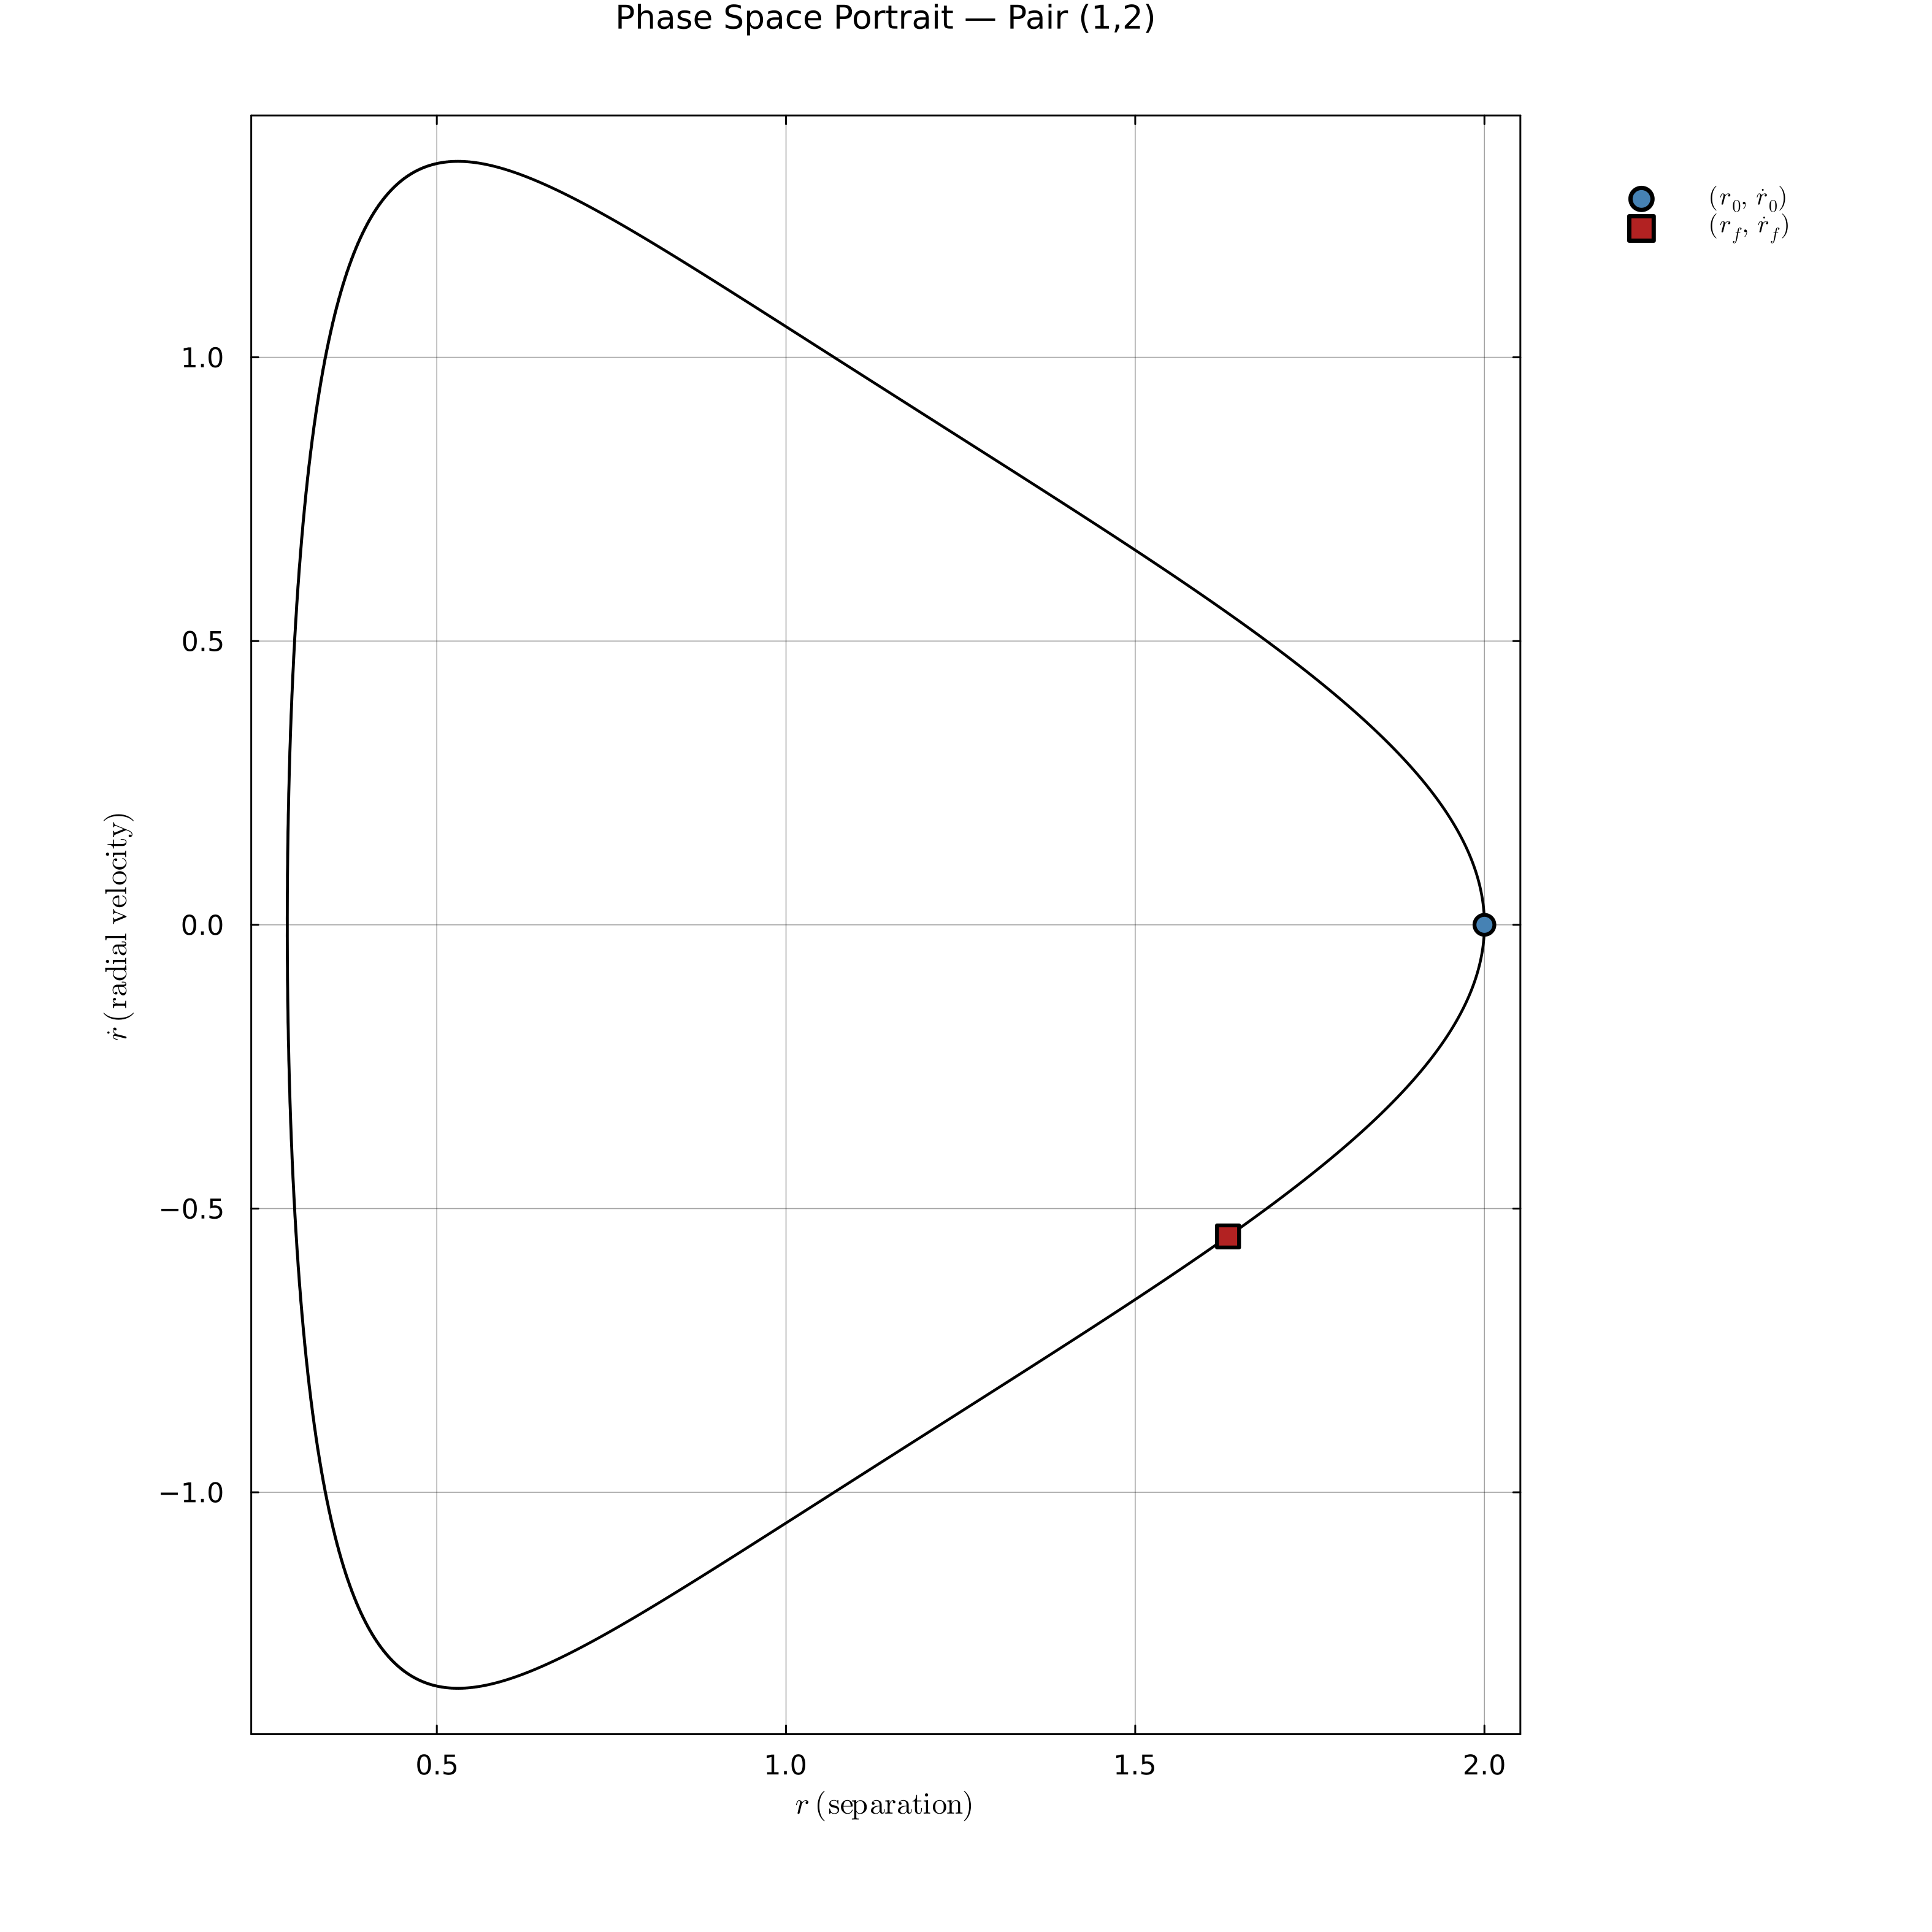

In [17]:
ps = forces.phase_space
println("Min separation: ", round(minimum(ps.separation_distance), digits = 4))
println("Max separation: ", round(maximum(ps.separation_distance), digits = 4))

plot_phase_space(forces)

## 11. Momentum Conservation

`plot_momentum_errors` stacks linear $\|\Delta\mathbf{P}\|$ and angular $|\Delta L_z|$ drift on log-scale panels. In the COM frame $\mathbf{P}_0 = 0$, so only the absolute linear drift is reported; angular momentum $L_{z,0} = 1/2$ also gets a relative-drift figure.

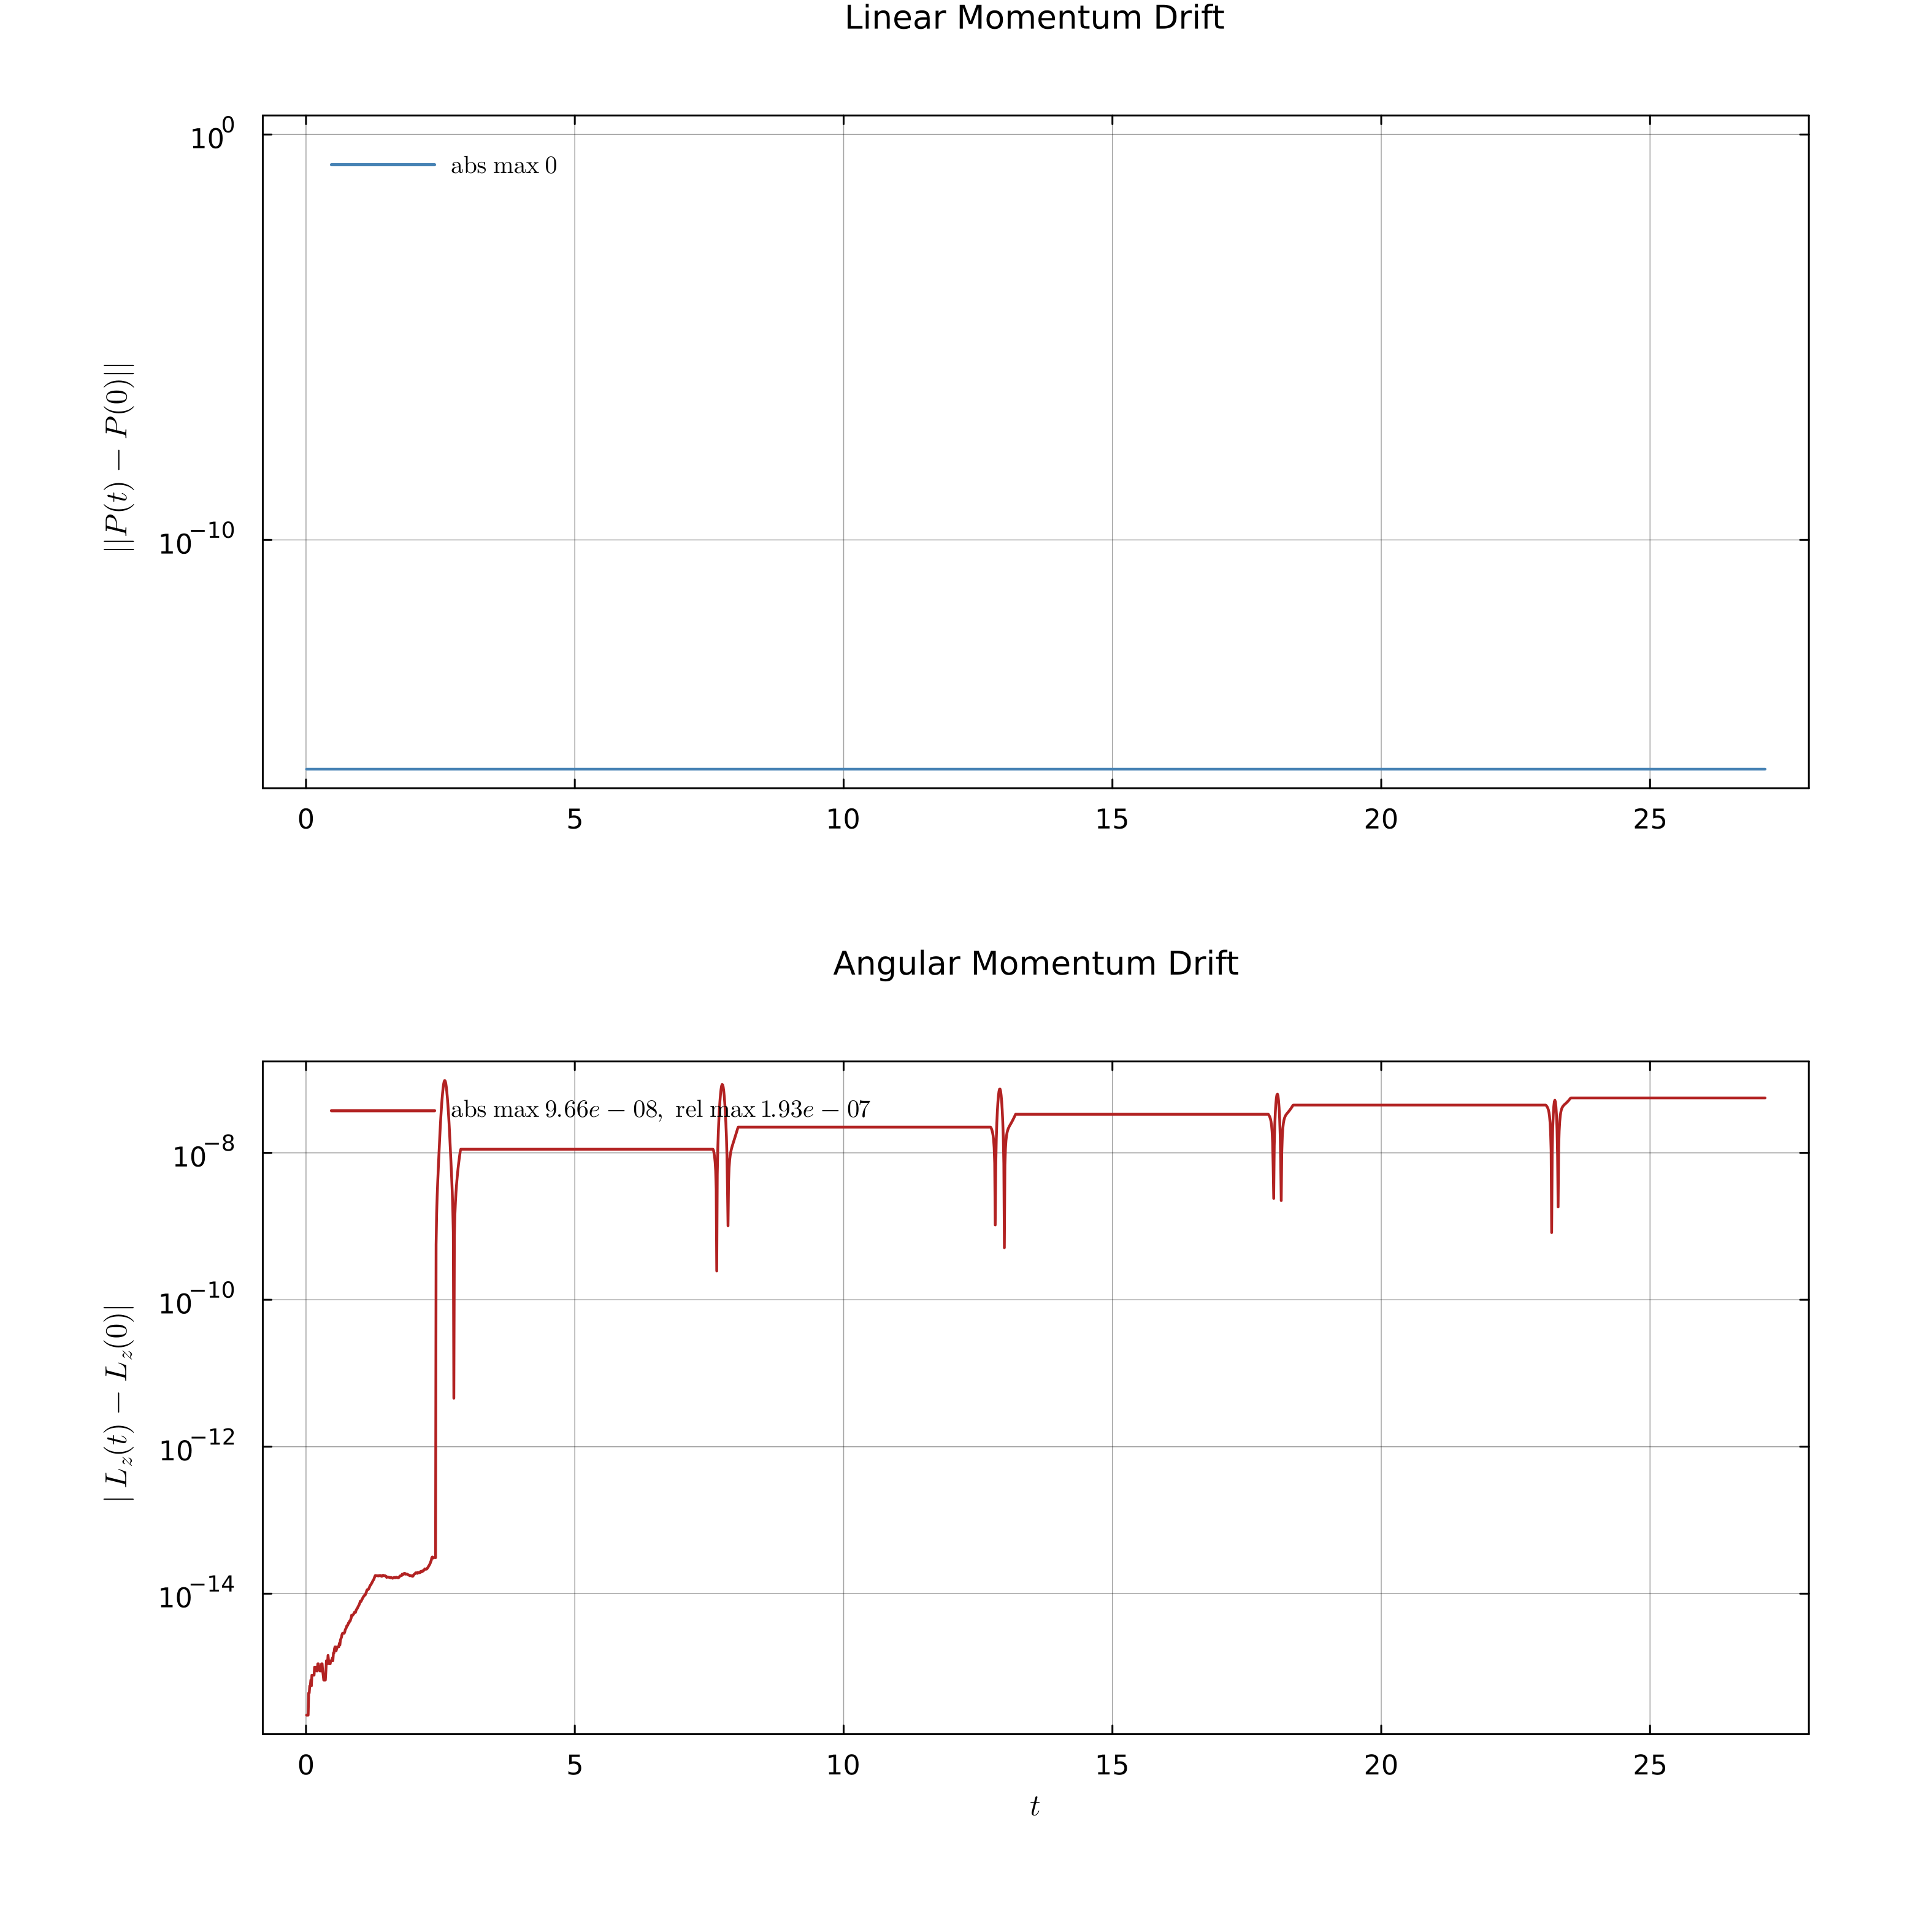

In [18]:
momentum = compute_momentum_timeseries(sol; stride = 10)
plot_momentum_errors(momentum)

## 12. Comparison Summary

Print full regularization diagnostics for both runs, then compare the final-state position delta and max energy drift between the two.

In [19]:
print_reg_diagnostics(sol;      label = "regularized")
println()
print_reg_diagnostics(sol_base; label = "baseline")

energy_base = compute_energy_timeseries(sol_base; stride = 10)

println()
println("--- Comparison ---")
@printf("Final position delta       : %.3e\n", final_position_delta(sol, sol_base))
@printf("Energy drift %% (regularized): %.3e\n", energy_drift_percent(energy))
@printf("Energy drift %% (baseline)   : %.3e\n", energy_drift_percent(energy_base))

[regularized] retcode                  = Success
[regularized] requested_backend        = lifted_pair


[regularized] used_backend             = lifted_pair
[regularized] active_steps             = 2311
[regularized] pair_steps               = 2311
[regularized] adaptive_pair_steps      = 0
[regularized] lifted_pair_steps        = 2311
[regularized] chain_steps              = 0
[regularized] unregularized_steps      = 24830
[regularized] backend_fallback_steps   = 0
[regularized] total_substeps           = 30382
[regularized] max_substeps_used        = 3
[regularized] activation_count         = 5
[regularized] deactivation_count       = 5
[regularized] min_encounter_distance   = 0.285714
[regularized] max_constraint_violation = 0.000e+00



[baseline] retcode                  = Success
[baseline] requested_backend        = disabled
[baseline] used_backend             = disabled
[baseline] active_steps             = 0
[baseline] pair_steps               = 0
[baseline] adaptive_pair_steps      = 0
[baseline] lifted_pair_steps        = 0
[baseline] chain_steps              = 0
[baseline] unregularized_steps      = 27141
[baseline] backend_fallback_steps   = 0
[baseline] total_substeps           = 27141
[baseline] max_substeps_used        = 1
[baseline] activation_count         = 0
[baseline] deactivation_count       = 0
[baseline] min_encounter_distance   = Inf
[baseline] max_constraint_violation = 0.000e+00

--- Comparison ---
Final position delta       : 9.981e-05
Energy drift % (regularized): 1.431e-04
Energy drift % (baseline)   : 4.281e-03
